In [9]:
import numpy as np

In [36]:
def lqr(A, B, F, N, N_T):
    """
    Calculate the feedback gains by backpropagation of the Riccati equation
    Accept:
        F: state cost in final position, size (n,n)
        A: dynamics matrix, size (n,n)
        B: input matrix, size (n,d)
        N: cost of control, size (d,d)
        N_T: number of time steps, int.
    Returns:
        V: sequence of cost matrices, size (n,n,N_T)
        L: sequence of feedback matrix, size (d,n,N_T)
    """
    n, d = B.shape
    V = np.zeros((n,n,N_T))
    L = np.zeros((d,n,N_T))
    
    V[:,:,-1] = F
    # Run backward in time
    for t in range(N_T-2,0,-1):
        """ Your code here """
        L[:,:,t] = np.linalg.inv((N + B.T @ V[:,:,t+1] @ B)) @ B.T @ V[:,:,t+1] @ A
        # below, addition of matrix M is missing
        V[:,:,t] = A.T @ V[:,:,t+1] @ A - A.T @ V[:,:,t+1] @ B @ np.linalg.inv((N + B.T @ V[:,:,t+1] @ B)) @ B.T @ V[:,:,t+1] @ A
        # V[:,:,t] = A.T @ V[:,:,t+1] @ A - A.T @ V[:,:,t+1] @ B @ L[:,:,t] ?
    return V, L

In [37]:
def simulate(x0, x0_est, A_real, A, B, C, L, 
                obs_noise, dyn_noise, init_var, dt):
    """
    Simultaneously simulate the trajectory forward and estimate the state
    Accepts:
        x0: initial position, size (n, )
        x0_est: estimate of initial position, size (n, )
        A_real: dynamics matrix - real, size (n,n)
        A: dynamics matrix - assumed, size (n,n)
        B: input matrix, size (n,d)
        C: observation matrix, size (d, n)
        L: sequence of feedback matrices, size (d, n, N_T)
        obs_noise: observation noise, float >=0
        dyn_noise: dynamics noise, float >=0
        init_var: initial variance of filter, float >=0
    Returns:
        x: true state, size (n, N_T)
        x_est: estimated state, size (n, N_T)
        x_var_est: sequence of posterior variances, size (n, n, N_T)
        kalman_gain: feedback matrices, size (n, d, N_T)
        u: controls, size (d, N_T)
    """
    # Initialize variables
    d, n, N_T = L.shape
    x = np.zeros((n,N_T))
    u = np.zeros((d,N_T-1))
    x_est = np.zeros((n,N_T))
    x_var_est = np.zeros((n,n,N_T))
    kalman_gain = np.zeros((n,d,N_T))
    
    x[:,0] = x0 # the true state
    x_est[:,0] = x0_est # system does not know where it is
    x_var_est[:,:,0] = init_var * np.eye(n) # very large state uncertainty at the beginning. 
    # observation noise matrix
    Q = obs_noise * dt * np.eye(d)
    # dynamics noise matrix
    R = dyn_noise * dt * np.eye(n)

    # Run forward in time
    for t in range(1, N_T):
        """ Your code here """
        u[:, t-1] = -L[:, :, t-1] @ x_est[:, t-1] # determine action

        x[:,t] = A_real @ x[:,t-1] + B @ u[:,t-1] # true evolution

        x_est[:,t] = A @ x_est[:,t-1] + B @ u[:,t-1]
        x_var_est[:,:,t] = A @ x_var_est[:,:,t-1] @ A.T + R
        
        kalman_gain[:,:,t] = x_var_est[:,:,t] @ C.T @ np.linalg.inv(C @ x_var_est[:,:,t] @ C.T + Q)

        x_est[:,t] += kalman_gain[:,:,t] @ (C @ x[:,t] - C @ x_est[:,t])
        x_var_est[:,:,t] = (1 - kalman_gain[:,:,t] @ C) @ x_var_est[:,:,t]
        
    return x, x_est, x_var_est, kalman_gain, u

In [55]:
x = np.array([0, -10, 0, 0])
obs_noise = 0.1**0.5
dyn_noise = 0.1**0.5
dt = 0.001
n = 4
f0 = 0
N_T = 100
A = np.stack(
    (
        np.array([1, 0, dt, 0]),
        np.array([0, 1, 0, dt]),
        np.array([0, 0, 1, -f0*dt]),
        np.array([0, 0, f0*dt, 1])
    ),
)
B = np.stack(
    (
        np.array([0, 0]),
        np.array([0, 0]),
        np.array([dt, 0]),
        np.array([0, dt])
    )
)
C = np.stack((np.array([1,0,0,0]), np.array([0,1,0,0])))
F = 10e8 * np.eye(n)
N = 10e2 * np.eye(2)


V, L = lqr(A=A, B=B, F=F, N=N, N_T=N_T)

x, x_est, x_var_est, kalman_gain, u = simulate(x0=x, x0_est=x, A_real=A, A=A, B=B, C=C, L=L, obs_noise=obs_noise, dyn_noise=dyn_noise, init_var=10e4, dt=dt)

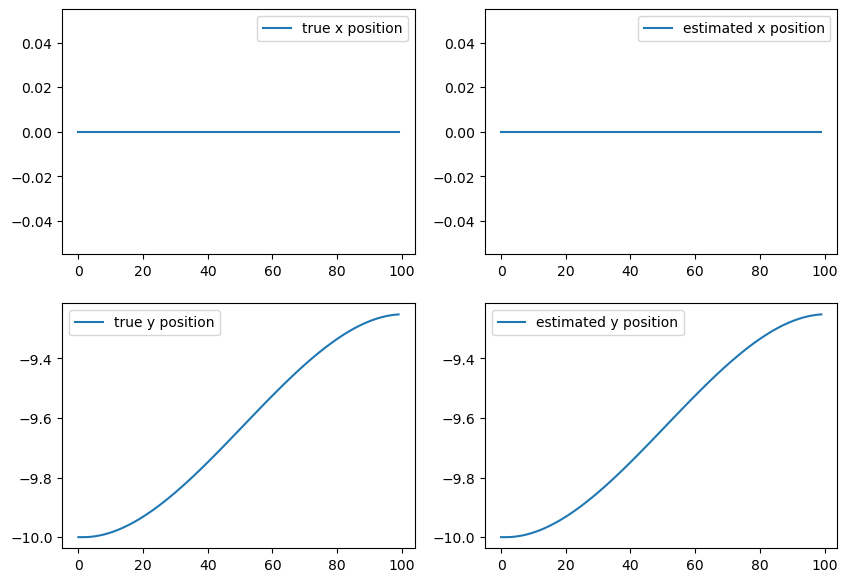

In [56]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(10, 7))
ax[0][0].plot(range(N_T), x[0,:], label='true x position')
ax[0][0].legend()
ax[0][1].plot(range(N_T), x_est[0,:], label='estimated x position')
ax[0][1].legend()
ax[1][0].plot(range(N_T), x[1,:], label='true y position')
ax[1][0].legend()
ax[1][1].plot(range(N_T), x_est[1,:], label='estimated y position')
ax[1][1].legend()
plt.show()